# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [1]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
            nn.init.zeros_(self.bias)
        else:
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x.matmul(self.weight.t())
        if self.bias is not None:
            y = y + self.bias
        return y

In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        # embedding is learnable because we hope that the model can learn an embedding where similar tokens have similar embeddings
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # e.g. for p = 0.1, mask is 0 with prob 0.1 and 1/(1-0.1) = 1.11 with prob 0.9
        mask = (torch.rand_like(x) > self.p).float() / (1 - self.p)
        
        return x * mask if self.training else x

# sanity check
# dropout = Dropout(p=0.7)
# dropout.train()
# x = torch.ones(10)
# print(dropout(x))  # should have some zeros and some 3.33
# dropout.eval()
# print(dropout(x))  # should be all ones

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [5]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            # should not happen because we may assume elementwise_affine to be True.
            self.register_parameter('weight', None)
            self.register_parameter('bias', None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            x_normalized = x_normalized * self.weight + self.bias
        return x_normalized
    
# sanity check
# create x of shape (B, T, D) where B=2, T=3, D=4 where last dimension has mean 5 and variance 2 and then apply layer norm and check that the output has mean 0 and variance 1
# x = torch.randn(2, 3, 4) * torch.sqrt(torch.tensor(2.0)) + 5.0
# layer_norm = LayerNorm(normalized_shape=4)
# x_normalized = layer_norm(x)
# print(x_normalized.mean(dim=-1))  # should be close to 0
# print(x_normalized.var(dim=-1, unbiased=False))  # should be close to 1

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(depth):
            input_dim = in_dim if i == 0 else hidden_dim
            output_dim = out_dim if i == depth - 1 else hidden_dim
            self.layers.append(Linear(input_dim, output_dim))
            if i < depth - 1:  # no activation after the last layer
                self.layers.append(nn.GELU())
                if use_layernorm:
                    self.layers.append(LayerNorm(hidden_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

In [8]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.net = nn.Sequential(
            Linear(d_model, d_ff),
            nn.GELU(),
            Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# TODO: define the dataloaders
batch_size = 64
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# print(next(iter(train_dl))[0].shape)  # should be torch.Size([64, 1, 28, 28])
# print(next(iter(test_dl))[1].shape)  # should be torch.Size([64])

In [12]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_softmax = torch.nn.functional.log_softmax(logits, dim=-1)
    # log_softmax[b] is a vector of length C,
    # where each element log_softmax[b, c] is the scalar log(exp(logits[b, c]) / sum_c' exp(logits[b, c'])) which is the log-probability of class c for sample b.
    batch_size = logits.size(0)
    batch_indices = torch.arange(batch_size) # tensor([0, 1, 2, ..., B-1])
    log_probabilities = log_softmax[batch_indices, targets] 
    # tensor of shape (B,) where each element is the log-probability of the correct class for each sample
    # e.g. if targets[0] = 3, then log_probabilities[0] = log_softmax[0, 3] which is the log-probability that the model assigned to class 3 for sample 0.
    # hopefully this probability was high (close to 1) so that log_probabilities[0] is close to 0.
    # if the probability was low, (close to 0), log_probabilities[0] would be a large negative number, which will contribute a large positive number to the loss after we take the negative.
    loss = -log_probabilities.mean() # mean over the batch
    return loss

# sanity check
# logits = torch.tensor([[0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 0.0, 0.0, 0.0, 0.0]]) # batch size 1, 9 classes, model is very confident that the correct class is 5
# target_1 = torch.tensor([5]) # correct class is 5
# target_2 = torch.tensor([0]) # correct class is now 0, but model still thinks it's 5
# print("good (model thinks 5, correct class is 5):")
# print(cross_entropy_from_logits(logits, target_1))
# print("bad (model thinks 5, correct class is 0):")
# print(cross_entropy_from_logits(logits, target_2))

In [13]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # convert from d_in to num_classes logits (no activation as we will apply cross-entropy loss which includes log-softmax)
        self.layer = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.layer(x)

In [14]:
def accuracy(loader: DataLoader, model: nn.Module) -> float:
    # IMPORTANT: I changed the function signature to take `model` as an argument too.
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader: # load a batch
            # flatten images (B, 1, 28, 28) -> (B, 784)
            x = images.view(images.size(0), -1)
            # forward pass to get logits
            logits = model(x)
            # get indicies of predictions (argmax of logits) for each sample in the batch
            predictions = torch.argmax(logits, dim=-1)

            # bookkeeping
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


In [15]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    # bookkeeping for plotting
    losses = []
    for epoch in range(epochs):
        model.train()
        for images, labels in train_data_loader:
            # flatten images (B, 1, 28, 28) -> (B, 784)
            x = images.view(images.size(0), -1)
            # forward pass to get logits
            logits = model(x)
            # compute loss
            loss = cross_entropy_from_logits(logits, labels)
            losses.append(loss.item())
            # backward pass and optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        test_acc = accuracy(test_data_loader, model)
        print(f"Epoch {epoch+1}/{epochs}, Test Accuracy: {test_acc:.4f}")
    return losses


In [16]:
# training:
model = nn.Sequential(MLP(in_dim=28*28, hidden_dim=256, out_dim=64, depth=3, use_layernorm=True), ClassificationHead(d_in=64, num_classes=10))
losses = train_classifier(model, train_dl, test_dl, lr=1e-3, epochs=5)

Epoch 1/5, Test Accuracy: 0.9665
Epoch 2/5, Test Accuracy: 0.9646
Epoch 3/5, Test Accuracy: 0.9730
Epoch 4/5, Test Accuracy: 0.9778
Epoch 5/5, Test Accuracy: 0.9736


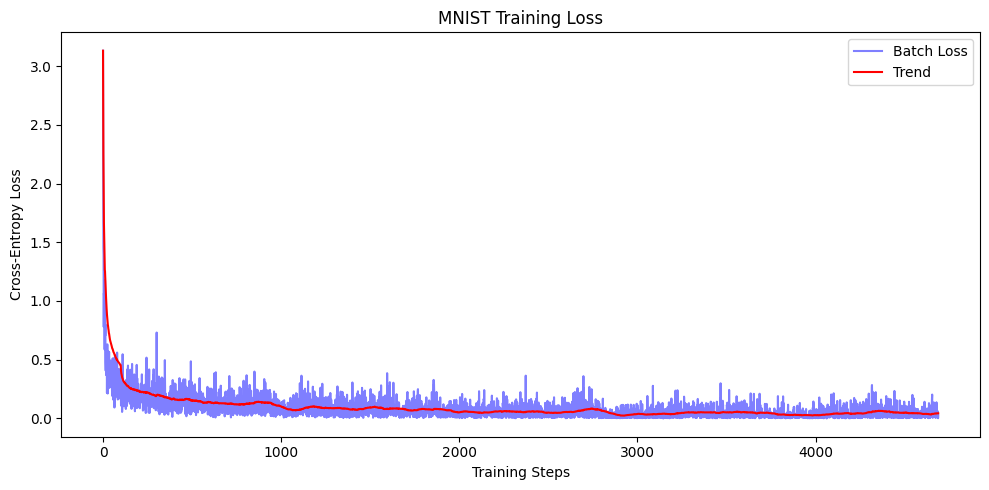

In [17]:
import matplotlib.pyplot as plt # uv pip install matplotlib
import numpy as np

def expanding_moving_average(values, window):
    v = np.array(values)
    c = np.cumsum(np.insert(v, 0, 0))
    
    out = []
    for i in range(1, len(v) + 1):
        if i < window:
            # Expanding: average of all points seen so far
            out.append(c[i] / i)
        else:
            # Sliding: average of the last 'window' points
            out.append((c[i] - c[i - window]) / window)
    return out

def plot_training_results(losses: list[float]):
    window_size = 100
    moving_avg = expanding_moving_average(losses, window=window_size)
    assert len(losses) == len(moving_avg)

    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Batch Loss', color='blue', alpha=0.5)
    plt.plot(moving_avg, label='Trend', color='red')
    
    plt.title("MNIST Training Loss")
    plt.xlabel("Training Steps")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.tight_layout()
    
    plt.savefig('training_loss.png')
    plt.show()

plot_training_results(losses)